# Teiko Technical Assessment EDA

In [60]:
import pandas as pd

df = pd.read_csv('cell-count.csv')
df.head(18)


,project,subject,condition,age,sex,treatment,response,sample,sample_type,time_from_treatment_start,b_cell,cd8_t_cell,cd4_t_cell,nk_cell,monocyte
0,prj1,sbj000,melanoma,57,M,miraclib,no,sample00000,PBMC,0,10908,24440,20491,13864,23511
1,prj1,sbj000,melanoma,57,M,miraclib,no,sample00001,PBMC,7,6777,19407,33459,18170,23011
2,prj1,sbj000,melanoma,57,M,miraclib,no,sample00002,PBMC,14,9794,22940,24274,17482,18332
3,prj1,sbj001,carcinoma,68,M,miraclib,yes,sample00003,PBMC,0,10081,20271,36157,14041,12610
4,prj1,sbj001,carcinoma,68,M,miraclib,yes,sample00004,PBMC,7,4372,33778,38293,16527,14933
5,prj1,sbj001,carcinoma,68,M,miraclib,yes,sample00005,PBMC,14,15431,31940,30805,11404,15779
6,prj1,sbj002,melanoma,50,M,miraclib,no,sample00006,PBMC,0,5897,31296,28319,12656,21606
7,prj1,sbj002,melanoma,50,M,miraclib,no,sample00007,PBMC,7,10403,13504,33870,22616,18031
8,prj1,sbj002,melanoma,50,M,miraclib,no,sample00008,PBMC,14,8829,26215,21307,17624,16378
9,prj1,sbj003,melanoma,52,M,miraclib,no,sample00009,PBMC,0,7650,33334,21097,18064,15676


Columns

In [61]:
df.columns

Index(['project', 'subject', 'condition', 'age', 'sex', 'treatment',
       'response', 'sample', 'sample_type', 'time_from_treatment_start',
       'b_cell', 'cd8_t_cell', 'cd4_t_cell', 'nk_cell', 'monocyte'],
      dtype='object')

Shape

In [62]:
df.shape

(10500, 15)

We are going to extract repeated information, by step of 3 each time. so that should be 10500 / 3 rows 

In [63]:
df.shape[0] / 3

3500.0

Count how many NAs

In [64]:
df.isna().sum()

project                         0
subject                         0
condition                       0
age                             0
sex                             0
treatment                       0
response                     1422
sample                          0
sample_type                     0
time_from_treatment_start       0
b_cell                          0
cd8_t_cell                      0
cd4_t_cell                      0
nk_cell                         0
monocyte                        0
dtype: int64

In [65]:
df[df['response'].isna()].head(3)

,project,subject,condition,age,sex,treatment,response,sample,sample_type,time_from_treatment_start,b_cell,cd8_t_cell,cd4_t_cell,nk_cell,monocyte
30,prj1,sbj010,healthy,70,M,none,NaN,sample00030,PBMC,0,6413,25167,20437,22317,19638
31,prj1,sbj010,healthy,70,M,none,NaN,sample00031,PBMC,7,7007,30482,31653,14167,23316
32,prj1,sbj010,healthy,70,M,none,NaN,sample00032,PBMC,14,11118,19704,32582,20603,17350


It seems treatments with `'none'` are given a `Nan` `response` value. 
Let's value_counts() the treatments of this subquery.

In [66]:
df[df['response'].isna()][['treatment']].value_counts()

treatment
none         1422
Name: count, dtype: int64

Yes. All are from `none` treatments.

Show NaNs

Types of projects `project`

In [67]:
df[['project']].value_counts()

project
prj1       4500
prj2       3000
prj3       3000
Name: count, dtype: int64

Types of Sample types `sample_type`

In [68]:
df[['sample_type']].value_counts()

sample_type
PBMC           7500
WB             3000
Name: count, dtype: int64

Types of Treatment `treatment` and counts 

In [69]:
df[['treatment']].value_counts()

treatment
miraclib     4695
phauximab    4383
none         1422
Name: count, dtype: int64

Types of Conditions `condition` counts

In [70]:
df[['condition']].value_counts()

condition
melanoma     5175
carcinoma    3903
healthy      1422
Name: count, dtype: int64

Ratio of `yes` and `no` responses frmo `response`

In [71]:
df[['response']].value_counts()

response
yes         4611
no          4467
Name: count, dtype: int64

Ratio of `male`/`female` `gender`

In [72]:
df[['sex']].value_counts()

sex
M      5430
F      5070
Name: count, dtype: int64

The `time_from_treatment_start` is always `0`,`7`,`14`

In [73]:
df[['time_from_treatment_start']].value_counts()

time_from_treatment_start
0                            3500
7                            3500
14                           3500
Name: count, dtype: int64

Analyze **how** the drug affects the four(4) *immune cell population* aka, `b_cell`,`cd8_t_cell`,`cd4_t_cell`,`nk_cell`

## Part 1 : Data Management (go to `load_data.py`)

We need three(3) tables:
Subject:
- subject_id
- subject
- condition
- project
- age
- sex

Treatment:
- subject_id
- treatment_id
- treatment
- response 

Sample:
- sample_id
- subject_id
- sample
- sample_type
- time_from_treatment_start
- b_cell
- cd8_t_cell
- cd4_t_cell
- nk_cell
- monocyte 

In [74]:
Subject = df[['subject', 'condition', 'project', 'age', 'sex']].iloc[::3]
Subject

,subject,condition,project,age,sex
0,sbj000,melanoma,prj1,57,M
3,sbj001,carcinoma,prj1,68,M
6,sbj002,melanoma,prj1,50,M
9,sbj003,melanoma,prj1,52,M
12,sbj004,carcinoma,prj1,77,M
...,...,...,...,...,...
10485,sbj3495,carcinoma,prj3,74,M
10488,sbj3496,carcinoma,prj3,50,M
10491,sbj3497,melanoma,prj3,71,M
10494,sbj3498,melanoma,prj3,67,M


# Part 3 : Binary Classifier 

- Binary Classifier for predicting yes/no response using cell population frequencies 
- How should we approach this as time is an indicator? 

Don't worry about the `'none'` treatment `NaN`s because we are only looking at `miraclib` rows that are `'PBMC'` 

- Change of each cell population ? Like 0-7 it went up/down x amount after miraclib and 7-14 it went up/down x amount after miraclib 

We ideally want to query all the treatment records who have only `'miraclib'` treatment, inner join those whose `'subject'` foreignkey/primarykey 
matches on the `Subject` table rows. This will give us every subject row with miraclib treatment. 

Then match that new table on the `Sample` table using the `'subject'` foreignkey/primarykey. 
This will give us every sample row that is miraclib and subject data with their sample data (3 rows each). 

Then match THAT table on the `CellFrequency` table using the `'sample'` foreignkey/primary key maatches. there! Innerjoining all these should give us specifically cell frequencies that are miraclib treatments. 

In [75]:
import sqlite3
import seaborn as sns

with sqlite3.connect('databaseSchema.db') as conn:
    curr = conn.cursor()

    #Every 15 records are 1 patient with condition Melanoma on miraclib treatment for PCMB sample_types.
    #5 records for the cell populations 0 weeks of using miraclib to treat melanoma, then 7 weeks, then 14 weeks. (15 records total)
    curr.execute(
        """
        SELECT cf.sample, Sample.subject, cf.population, cf.percentage, cf.count, cf.total_count, Sample.time_from_treatment_start, Treatment.response FROM CellFrequency cf
        INNER JOIN Sample ON cf.sample = Sample.sample 
        INNER JOIN Subject ON Sample.subject = Subject.subject 
        INNER JOIN Treatment ON Subject.subject = Treatment.subject 
        WHERE Treatment.treatment = "miraclib" AND Subject.condition = "melanoma" AND Sample.sample_type = "PBMC"; 
        """
    )
    
    results = curr.fetchall()
    for result in results:
        print(result)
conn.close()
    

('sample00000', 'sbj000', 'b_cell', 11.702104834037806, 10908, 93214, '0', 'no')
('sample00000', 'sbj000', 'cd4_t_cell', 21.98274937241187, 20491, 93214, '0', 'no')
('sample00000', 'sbj000', 'cd8_t_cell', 26.21923745360139, 24440, 93214, '0', 'no')
('sample00000', 'sbj000', 'monocyte', 25.222606046302058, 23511, 93214, '0', 'no')
('sample00000', 'sbj000', 'nk_cell', 14.873302293646878, 13864, 93214, '0', 'no')
('sample00001', 'sbj000', 'b_cell', 6.721613901452035, 6777, 100824, '7', 'no')
('sample00001', 'sbj000', 'cd4_t_cell', 33.1855510592716, 33459, 100824, '7', 'no')
('sample00001', 'sbj000', 'cd8_t_cell', 19.248393239704832, 19407, 100824, '7', 'no')
('sample00001', 'sbj000', 'monocyte', 22.822938982781878, 23011, 100824, '7', 'no')
('sample00001', 'sbj000', 'nk_cell', 18.021502816789653, 18170, 100824, '7', 'no')
('sample00002', 'sbj000', 'b_cell', 10.551377906099848, 9794, 92822, '14', 'no')
('sample00002', 'sbj000', 'cd4_t_cell', 26.151127965353044, 24274, 92822, '14', 'no')
('

In [ ]:
import sqlite3
import seaborn as sns

with sqlite3.connect('databaseSchema.db') as conn:
    curr = conn.cursor()

    df = pd.read_sql_query("""
            SELECT cf.sample, Sample.subject, cf.population, cf.percentage, cf.count, cf.total_count, Sample.time_from_treatment_start, Treatment.response FROM CellFrequency cf
            INNER JOIN Sample ON cf.sample = Sample.sample
            INNER JOIN Subject ON Sample.subject = Subject.subject
            INNER JOIN Treatment ON Subject.subject = Treatment.subject
            WHERE Treatment.treatment = "miraclib" AND Subject.condition = "melanoma" AND Sample.sample_type = "PBMC";
            """, conn)

conn.close()

,sample,subject,population,percentage,count,total_count,time_from_treatment_start,response
0,sample00000,sbj000,b_cell,11.702105,10908,93214,0,no
1,sample00000,sbj000,cd4_t_cell,21.982749,20491,93214,0,no
2,sample00000,sbj000,cd8_t_cell,26.219237,24440,93214,0,no
3,sample00000,sbj000,monocyte,25.222606,23511,93214,0,no
4,sample00000,sbj000,nk_cell,14.873302,13864,93214,0,no


Box Plot of the data 

maybe for each amount of weeks into treatment. 
Boxplot for those 0 weeks into treatment, then 7, then 14. and two boxplots for yes response and for no response 
Part 3: Statistical Analysis

As the trial progresses, Bob wants to identify patterns that might predict treatment response and share those findings with his colleague, Yah D’yada. Using the data reported in the summary table, your program should provide functionality to:

Compare the differences in cell population relative frequencies of melanoma patients receiving miraclib who respond (responders) versus those who do not (non-responders), with the overarching aim of predicting response to the treatment miraclib. Response information can be found in column "response", with value "yes" for responding and value "no" for non-responding. Please only include PBMC samples.

Visualize the population relative frequencies comparing responders versus non-responders using a boxplot of for each immune cell population.

Report which cell populations have a significant difference in relative frequencies between responders and non-responders. Statistics are needed to support any conclusion to convince Yah of Bob’s findings. 

In [77]:
df.head(15)

,sample,subject,population,percentage,count,total_count,time_from_treatment_start,response
0,sample00000,sbj000,b_cell,11.702105,10908,93214,0,no
1,sample00000,sbj000,cd4_t_cell,21.982749,20491,93214,0,no
2,sample00000,sbj000,cd8_t_cell,26.219237,24440,93214,0,no
3,sample00000,sbj000,monocyte,25.222606,23511,93214,0,no
4,sample00000,sbj000,nk_cell,14.873302,13864,93214,0,no
5,sample00001,sbj000,b_cell,6.721614,6777,100824,7,no
6,sample00001,sbj000,cd4_t_cell,33.185551,33459,100824,7,no
7,sample00001,sbj000,cd8_t_cell,19.248393,19407,100824,7,no
8,sample00001,sbj000,monocyte,22.822939,23011,100824,7,no
9,sample00001,sbj000,nk_cell,18.021503,18170,100824,7,no


C:\Users\chazc\AppData\Local\Temp\ipykernel_39664\3380039533.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x="percentage", y='response', palette='Set2')


<Axes: xlabel='percentage', ylabel='response'>

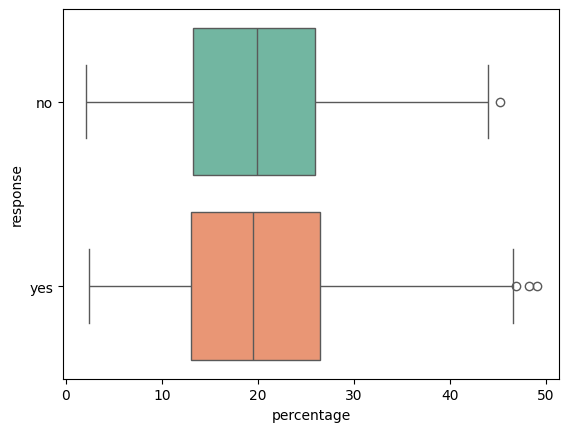

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt 
sns.boxplot(df, x="percentage", y='response', palette='Set2')

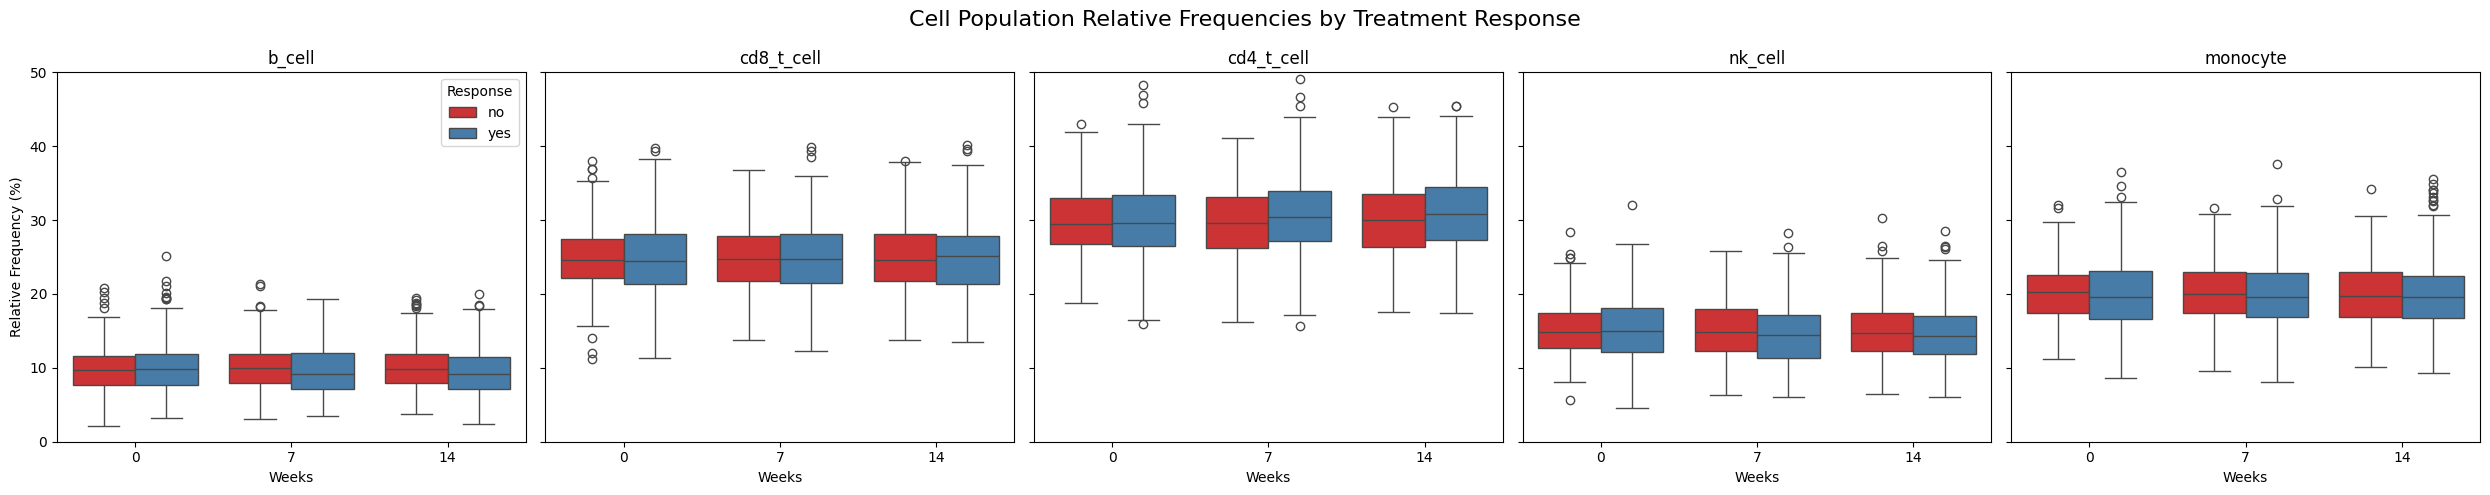

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

populations = [
    "b_cell",
    "cd8_t_cell",
    "cd4_t_cell",
    "nk_cell",
    "monocyte",
]

fig, axes = plt.subplots(
    1,
    5,
    figsize=(25, 5),
    sharey=True
)

for axis, population in zip(axes, populations):
    sns.boxplot(
        data=df[df["population"] == population],
        x="time_from_treatment_start",
        y="percentage",
        hue="response",
        palette="Set1",
        ax=axis
    )

    axis.set_title(population)
    axis.set_xlabel("Weeks")
    axis.set_ylim(0, 50)
    axis.set_ylabel("Relative Frequency (%)")

    # Avoid repeating a legend on every subplot
    if axis != axes[0]:
        axis.get_legend().remove()

axes[0].legend(title="Response")
fig.suptitle(
    "Cell Population Relative Frequencies by Treatment Response",
    fontsize=16
)

plt.tight_layout()
plt.show()

The boxplot's seem to show small changes and variations in eachother, for example, it seems cd4_t_cells generally lower lead to a response of 'no'
while generally higher cd4_t_cells lead to a response of 'yes'. 

Another is that samples of nk_cells that respond 'yes' are initially higher in the first time period, but once it reaches 7 weeks, higher cell count leads to less likely 
probability of responding 'yes'. 

Since this is a binary classification, we can use Logistic Regression, perform KFolds, crossvalidating our model, and seeing what coefficients 
have the highest magnitude on predicting `responses`. 

# Using logistic regression for Predictive Evidence, findings checked with statistical hypothesis testing. 


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Select only the fields needed for the prediction model.
model_df = df[["subject", "response", "population", "percentage", "time_from_treatment_start"]].copy()

model_df["time_from_treatment_start"] = model_df["time_from_treatment_start"].astype(int)

feature_table = model_df.pivot_table(index=["subject", "response"], columns=["population", "time_from_treatment_start"], values="percentage", aggfunc="first",)

feature_table.columns = [f"{population}_day{time}" for population, time in feature_table.columns]

feature_table = feature_table.reset_index()

# Add each subject's change from day 0 to day 14.
for population in populations:
    baseline_column = f"{population}_time:0"
    followup_column = f"{population}_time:14"
    change_column = f"{population}_change_14_minus_0"
    feature_table[change_column] = (
        feature_table[followup_column] - feature_table[baseline_column]
    )

feature_columns = [
    column for column in feature_table.columns
    if column not in ["subject", "response"]
]

X = feature_table[feature_columns]
y = (feature_table["response"] == "yes").astype(int)

# Standardize features and fit logistic regression.
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=2000)),
])

# Evaluate predictions on held-out subjects through five-fold cross-validation.
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
predicted_probabilities = cross_val_predict(
    model,
    X,
    y,
    cv=folds,
    method="predict_proba",
)[:, 1]
predicted_labels = (predicted_probabilities >= 0.5).astype(int)

print(f"Patients analyzed: {len(feature_table)}")
print(f"Yes responses: {y.sum()}")
print(f"No responses: {len(y) - y.sum()}")
print(f"Cross-validated ROC AUC: {roc_auc_score(y, predicted_probabilities):.3f}")
print(f"Cross-validated accuracy: {accuracy_score(y, predicted_labels):.3f}")
print("Confusion matrix [rows=actual, columns=predicted]:")
print(confusion_matrix(y, predicted_labels))
print(classification_report(y, predicted_labels, target_names=["no", "yes"]))

# Positive coefficients are associated with higher predicted yes probability.
model.fit(X, y)
coefficient_table = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": model.named_steps["classifier"].coef_[0],
})
coefficient_table["absolute_coefficient"] = coefficient_table[
    "coefficient"
].abs()
coefficient_table.sort_values(
    "absolute_coefficient", ascending=False
).head(15)

Patients analyzed: 656
Yes responses: 331
No responses: 325
Cross-validated ROC AUC: 0.532
Cross-validated accuracy: 0.526
Confusion matrix [rows=actual, columns=predicted]:
[[168 157]
 [154 177]]
              precision    recall  f1-score   support

          no       0.52      0.52      0.52       325
         yes       0.53      0.53      0.53       331

    accuracy                           0.53       656
   macro avg       0.53      0.53      0.53       656
weighted avg       0.53      0.53      0.53       656



,feature,coefficient,absolute_coefficient
4,cd4_t_cell_day7,0.143676,0.143676
13,nk_cell_day7,-0.095950,0.095950
5,cd4_t_cell_day14,0.093751,0.093751
2,b_cell_day14,-0.081475,0.081475
1,b_cell_day7,-0.078481,0.078481
15,b_cell_change_14_minus_0,-0.076607,0.076607
14,nk_cell_day14,-0.055993,0.055993
3,cd4_t_cell_day0,0.039802,0.039802
9,monocyte_day0,-0.039644,0.039644
17,cd4_t_cell_change_14_minus_0,0.038432,0.038432


Our model's accuracy_score and ROC AUC score comes out to around 53% accuracy. Which tells us it's level of accuracy given the data. 
It's possible this score could tell us that our current `CellFrequency` data may not be sufficient enough for 
predicting treatment responses. 

In [94]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Select only the fields needed for the two planned tests.
analysis_df = df[[
    "response",
    "population",
    "percentage",
    "time_from_treatment_start",
]].copy()
analysis_df["time_from_treatment_start"] = analysis_df[
    "time_from_treatment_start"
].astype(int)

# Test the two day-7 patterns suggested by logistic regression.
feature_tests = [
    {
        "feature": "cd4_t_cell_day7",
        "population": "cd4_t_cell",
        "alternative": "greater",
        "claim": "Higher CD4 day 7 percentage is associated with yes response",
    },
    {
        "feature": "nk_cell_day7",
        "population": "nk_cell",
        "alternative": "less",
        "claim": "Lower NK day 7 percentage is associated with yes response",
    },
]

feature_results = []

for test in feature_tests:
    feature_data = analysis_df[
        (analysis_df["population"] == test["population"]) &
        (analysis_df["time_from_treatment_start"] == 7)
    ]

    yes_values = feature_data.loc[
        feature_data["response"] == "yes", "percentage"
    ]
    no_values = feature_data.loc[
        feature_data["response"] == "no", "percentage"
    ]

    u_statistic, p_value = mannwhitneyu(
        yes_values,
        no_values,
        alternative=test["alternative"],
    )

    feature_results.append({
        "feature": test["feature"],
        "claim": test["claim"],
        "n_yes": len(yes_values),
        "n_no": len(no_values),
        "median_yes_percentage": yes_values.median(),
        "median_no_percentage": no_values.median(),
        "median_difference_yes_minus_no": (
            yes_values.median() - no_values.median()
        ),
        "u_statistic": u_statistic,
        "p_value": p_value,
    })

feature_results_df = pd.DataFrame(feature_results)

# Correct the two planned p-values with Holm's method.
feature_results_df["adjusted_p_value"] = multipletests(
    feature_results_df["p_value"],
    method="holm",
)[1]
feature_results_df["significant"] = (
    feature_results_df["adjusted_p_value"] < 0.05
)

feature_results_df.round(4)

,feature,claim,n_yes,n_no,median_yes_percentage,median_no_percentage,median_difference_yes_minus_no,u_statistic,p_value,adjusted_p_value,significant
0,cd4_t_cell_day7,Higher CD4 day 7 percentage is associated with...,331,325,30.4457,29.5476,0.8980,59064.0,0.0149,0.0297,True
1,nk_cell_day7,Lower NK day 7 percentage is associated with y...,331,325,14.4198,14.7959,-0.3761,50185.0,0.0689,0.0689,False
